In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import plotly.graph_objects as go
from plotly.subplots import make_subplots

Load Dataset  


In [5]:
df=pd.read_csv(r"C:\Users\Ravula preethi\Downloads\funnel_analysis_data.csv")

In [6]:
df.head()


,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No


In [7]:
df.sample()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
13807,USR06354,SES06354,Checkout,2025-10-04 22:38:11,Mobile,South,Social Media,Sports,0.0,Yes


In [8]:
df.columns

Index(['User_ID', 'Session_ID', 'Event', 'Timestamp', 'Device', 'Region',
       'Channel', 'Product_Category', 'Revenue', 'Bounce_Flag'],
      dtype='object')

In [9]:
df.dtypes

User_ID              object
Session_ID           object
Event                object
Timestamp            object
Device               object
Region               object
Channel              object
Product_Category     object
Revenue             float64
Bounce_Flag          object
dtype: object

In [10]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df.dtypes)

User_ID                     object
Session_ID                  object
Event                       object
Timestamp           datetime64[ns]
Device                      object
Region                      object
Channel                     object
Product_Category            object
Revenue                    float64
Bounce_Flag                 object
dtype: object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21663 entries, 0 to 21662
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           21663 non-null  object        
 1   Session_ID        21663 non-null  object        
 2   Event             21663 non-null  object        
 3   Timestamp         21663 non-null  datetime64[ns]
 4   Device            21663 non-null  object        
 5   Region            21663 non-null  object        
 6   Channel           21663 non-null  object        
 7   Product_Category  21663 non-null  object        
 8   Revenue           21663 non-null  float64       
 9   Bounce_Flag       21663 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 1.7+ MB


In [12]:
df.describe()

,Timestamp,Revenue
count,21663,21663.000000
mean,2025-10-16 19:56:22.920740608,54.304841
min,2025-10-01 19:30:17,0.000000
25%,2025-10-09 08:31:38,0.000000
50%,2025-10-16 19:47:21,0.000000
75%,2025-10-24 08:13:17,0.000000
max,2025-10-31 19:25:15,1998.510000
std,NaN,262.692471


In [13]:
df.describe(include='object')

,User_ID,Session_ID,Event,Device,Region,Channel,Product_Category,Bounce_Flag
count,21663,21663,21663,21663,21663,21663,21663,21663
unique,10000,10000,4,3,4,4,5,2
top,USR07731,SES07731,Browse,Tablet,West,Google Ads,Electronics,Yes
freq,4,4,10000,7237,5462,5435,4405,17343


In [14]:
df.shape

(21663, 10)

In [15]:
pd.set_option("display.max_rows",None)

In [16]:
null_values = df.isnull().sum()
print(null_values)

User_ID             0
Session_ID          0
Event               0
Timestamp           0
Device              0
Region              0
Channel             0
Product_Category    0
Revenue             0
Bounce_Flag         0
dtype: int64


In [17]:
duplicates_values = df.duplicated().sum()
print(f"total numbers of duplicate values in this dataset is {duplicates_values}")

total numbers of duplicate values in this dataset is 0


In [18]:
unique_data = df.nunique()
print(unique_data)

User_ID             10000
Session_ID          10000
Event                   4
Timestamp           21564
Device                  3
Region                  4
Channel                 4
Product_Category        5
Revenue              1078
Bounce_Flag             2
dtype: int64


In [19]:
df["Date"] = df['Timestamp'].dt.date
df["dayofweek"] = df['Timestamp'].dt.day_name()
df["hour"] = df['Timestamp'].dt.hour
df["weekNumber"] = df['Timestamp'].dt.isocalendar().week

In [20]:
df['Event_sequence'] = df.groupby('Session_ID').cumcount()+1

In [21]:
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Date,dayofweek,hour,weekNumber,Event_sequence
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes,2025-10-28,Tuesday,7,44,1
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes,2025-10-28,Tuesday,7,44,2
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes,2025-10-28,Tuesday,7,44,3
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No,2025-10-19,Sunday,9,42,1
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No,2025-10-19,Sunday,9,42,2


In [22]:
# BASIC STEPS
print(f'Total user ID { df['User_ID'].nunique()}')
print(f'\nTotal Session ID {df['Session_ID'].nunique()}')
print(f'\nDate range{df['Date'].min()} to {df['Date'].max()}')

Total user ID 10000

Total Session ID 10000

Date range2025-10-01 to 2025-10-31


Funnel Stage Definition and Session - Level Aggregation

In [23]:
# define funnel stages in order
funnel_stages = ['Browse','Add to Cart','Checkout','Purchase']
#create session -level summary
session_summary = df.groupby ('Session_ID').agg({
    'User_ID' : 'first',
    'Timestamp': ['min','max'],
    'Event': lambda x: list(x),
    'Device':'first',
    'Region':'first',
    'Channel': 'first' ,
    'Product_Category' : 'first',
    'Revenue' : 'max',
    'Bounce_Flag' : 'first'
}).reset_index()
# flatten column names 
session_summary.columns = ['Session_ID' , 'User_ID' , 'Session_Start' , 'Session_End' , 'Event_Sequence',
                           'Device' , 'Region' , 'Channel','product_category','Revenue','Bounce_Flag']
# calculation session duration in minutes 
session_summary['Session_Duration_Min'] = ( 
    session_summary ['Session_End'] - session_summary['Session_Start']
).dt.total_seconds()/60

# identify maximum funnel stage reached for each session 
def get_max_funnel_stage(events):
   stage_values = {stage : i for i , stage in enumerate (funnel_stages)}
   max_stage_index = -1
   for event in events:
     if event in stage_values and stage_values[event]>max_stage_index:
        max_stage_index = stage_values[event]
   return funnel_stages[max_stage_index] if max_stage_index != -1 else 'Browse'

session_summary['max_funnel_stage'] = session_summary['Event_Sequence'].apply(get_max_funnel_stage)

print("Session Summary Created:")
display(session_summary.head())

                                                

Session Summary Created:


,Session_ID,User_ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,product_category,Revenue,Bounce_Flag,Session_Duration_Min,max_funnel_stage
0,SES00001,USR00001,2025-10-28 07:33:50,2025-10-28 07:40:50,"[Browse, Add to Cart, Checkout]",Desktop,West,Organic,Home,0.00,Yes,7.0,Checkout
1,SES00002,USR00002,2025-10-19 09:15:10,2025-10-19 09:27:10,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Email,Electronics,448.18,No,12.0,Purchase
2,SES00003,USR00003,2025-10-12 02:19:00,2025-10-12 02:29:00,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Google Ads,Beauty,1437.19,No,10.0,Purchase
3,SES00004,USR00004,2025-10-05 17:55:48,2025-10-05 17:55:48,[Browse],Tablet,West,Social Media,Home,0.00,Yes,0.0,Browse
4,SES00005,USR00005,2025-10-19 12:35:49,2025-10-19 12:37:49,"[Browse, Add to Cart]",Tablet,West,Google Ads,Electronics,0.00,Yes,2.0,Add to Cart


Overall Funnel Analysis


In [24]:
#calculate overall funnel metrics
funnel_metrics = []
for i , stage in enumerate(funnel_stages):
    if i==0:
        # for Browse stage , count all sessions
        count = len(session_summary)
    else:
        # for  other stages , count sessions that reached at least this stage
        count = len(session_summary[session_summary['max_funnel_stage'].isin(funnel_stages[i:])])
    funnel_metrics .append({
     'stage':stage,
    'Sessions': count,
    'stage_order' : i
    })
funnel_df = pd.DataFrame(funnel_metrics)

# calculate conversion rates
funnel_df['Conversion_Rate'] = (funnel_df['Sessions']/funnel_df['Sessions'].iloc[0]*100).round(2)
funnel_df['Drop_off_Rate'] = (1-funnel_df['Sessions']/funnel_df['Sessions'].shift(1))*100
funnel_df['Drop_off_Rate'] .iloc[0] =0
funnel_df['Drop_off_Rate'] = funnel_df['Drop_off_Rate'].round(2)
print("overall Funnel Analysis:")
display(funnel_df)
# Revenue analysis
revenue_stats = session_summary[session_summary['max_funnel_stage'] == 'Purchase'].agg({
    'Revenue': ['sum','mean','count']
}).round(2)
print("\n Revenue Analysis:")
print(f"Total Revenue: ${revenue_stats.iloc[0,0]:,.2f}")
print(f"Average order value : $ { revenue_stats.iloc[1,0]:,.2f}")
print(f"total orders: { revenue_stats.iloc[2,0]:,}")

      

overall Funnel Analysis:


C:\Users\Ravula preethi\AppData\Local\Temp\ipykernel_2624\3491042747.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  funnel_df['Drop_off_Rate'] .iloc[0] =0
C:\Users\Ravula preethi\AppData\Local\Temp\ipykernel_2624\3491042747.py:20: Sett

,stage,Sessions,stage_order,Conversion_Rate,Drop_off_Rate
0,Browse,10000,0,100.00,0.00
1,Add to Cart,7059,1,70.59,29.41
2,Checkout,3524,2,35.24,50.08
3,Purchase,1080,3,10.80,69.35



 Revenue Analysis:
Total Revenue: $1,176,405.78
Average order value : $ 1,089.26
total orders: 1,080.0


Visualization - overall Funnel


In [25]:
# Create comprehensive funnel visualization
fig =  make_subplots(
    rows=2,cols=2,
    subplot_titles = ('Funnel Conversion Rates','Stage-to-Stage Drop-off',
                      'Revenue by Funnel Stage','Session Duration by Stage'),
    specs=[[{"secondary_y":False },{"secondary_y": False}],
           [{"secondary_y":False },{"secondary_y": False}]]
)
# funnel conversation rates
fig.add_trace(
    go.Bar(x=funnel_df['stage'], y=funnel_df['Sessions'],
           text = funnel_df['Sessions'],textposition='auto',
           name = ' Sessions',marker_color = 'lightblue'),
    row=1,col=1
)
#Drop-off rates
fig.add_trace(
    go.Scatter(x=funnel_df['stage'], y=funnel_df['Drop_off_Rate'],
              mode='lines+markers+text', text=funnel_df['Drop_off_Rate'],
              textposition='top center' , name = 'Drop-off Rate (%)',
              line=dict(color='red',width = 3)),
    row=1,col=2,secondary_y = False
)
# revenue by stage
revenue_by_stage = session_summary.groupby('max_funnel_stage')['Revenue'].sum().reset_index()
fig.add_trace(
    go.Bar(x=revenue_by_stage['max_funnel_stage'] , y= revenue_by_stage['Revenue'],
           text = [f'${x:,.0f}' for x in revenue_by_stage['Revenue']],
           textposition='auto', name= 'Revenue' , marker_color = 'green'),
    row=2,col=1
)
# session duration by stage
duration_by_stage = session_summary.groupby('max_funnel_stage')['Session_Duration_Min'].mean().reset_index()
fig.add_trace(
    go.Bar(x= duration_by_stage['max_funnel_stage'], y=duration_by_stage['Session_Duration_Min'],
           text= duration_by_stage['Session_Duration_Min'].round(2),
           textposition = 'auto',name='avg Session Duration (min)',
           marker_color = 'orange'),
    row=2 , col=2
)
fig.update_layout(height = 800, title_text = "Comprehensive Funnel Analysis Dashboard" , showlegend=False)
fig.show()


Channel Performance Analysis


Channel Performance Analysis:


,channel,Total_Sessions,Browse_sessions,Browse_Rate,Total_Revenue,AOV,Conversion_Rate,Add to Cart_sessions,Add to Cart_Rate,Checkout_sessions,Checkout_Rate,Purchase_sessions,Purchase_Rate
0,Organic,2511,2511,100.0,307448.35,1094.12,11.19,1802,71.76,900,35.84,281,11.19
1,Social Media,2440,2440,100.0,280071.63,1064.91,10.78,1734,71.07,861,35.29,263,10.78
2,Email,2489,2489,100.0,276116.54,1087.07,10.20,1740,69.91,877,35.24,254,10.20
3,Google Ads,2560,2560,100.0,312769.26,1109.11,11.02,1783,69.65,886,34.61,282,11.02


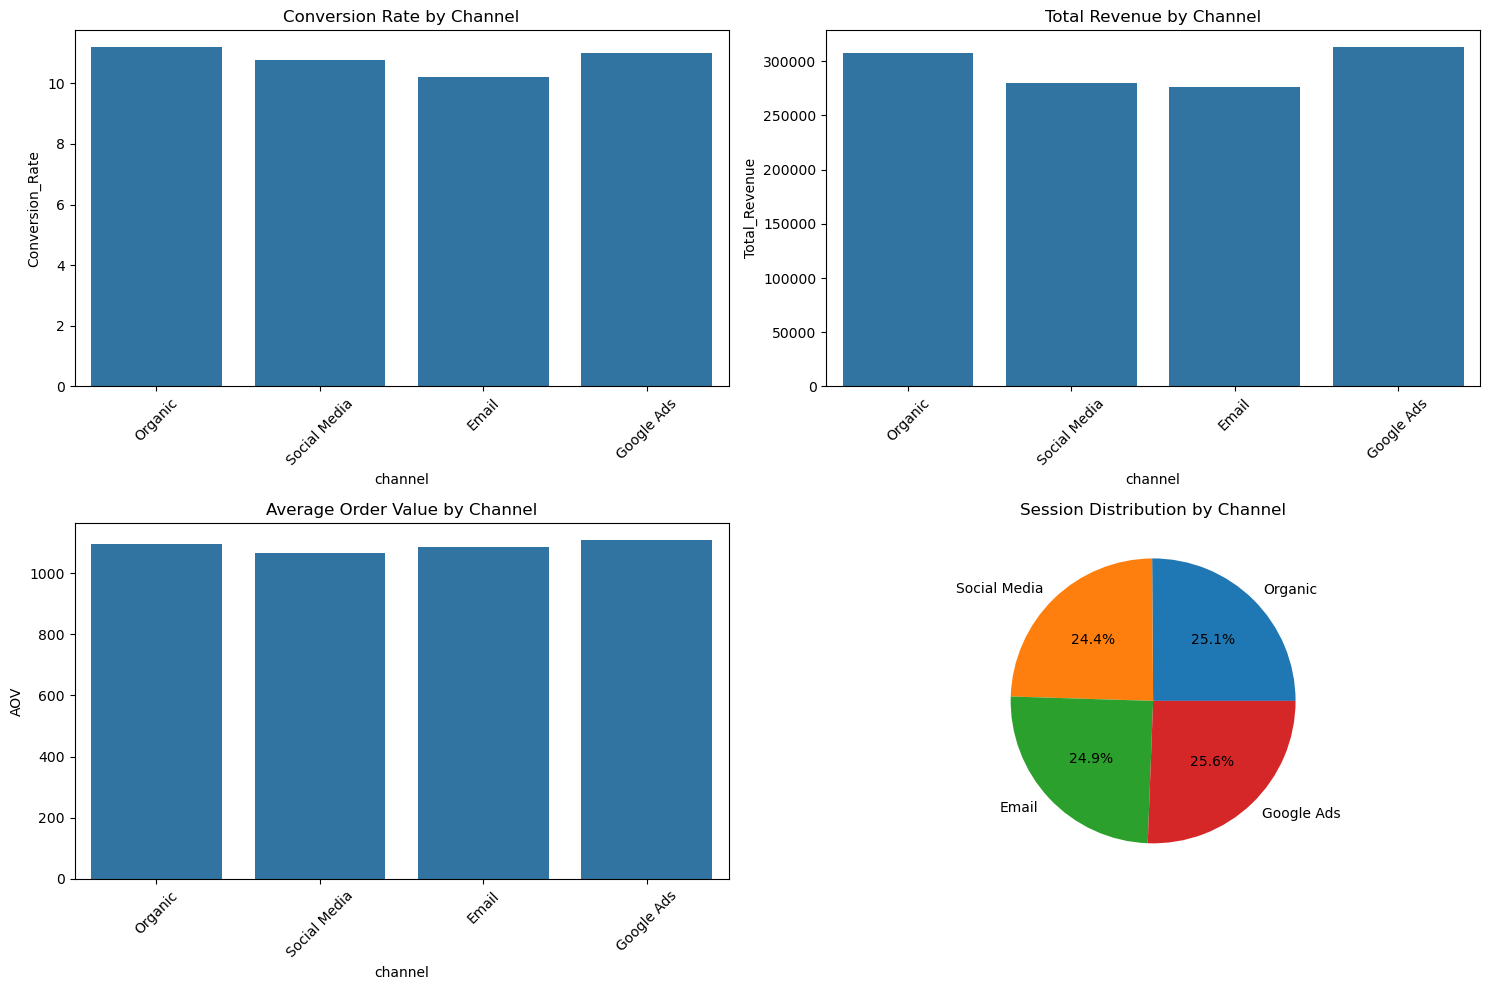

In [26]:
# Funnel analysis by channel
channel_funnel = []
for channel in df['Channel'].unique():
    channel_sessions = session_summary[session_summary['Channel']==channel]
    total_sessions = len(channel_sessions)
    if total_sessions>0:
        channel_metrics = {'channel':channel,'Total_Sessions': total_sessions}
        for i, stage in enumerate(funnel_stages):
            if i==0:
                count = total_sessions
            else:
                count = len(channel_sessions[channel_sessions['max_funnel_stage'].isin(funnel_stages[i:])])
            channel_metrics[f'{stage}_sessions'] = count
            channel_metrics[f'{stage}_Rate'] = (count/total_sessions*100)


            # revenue metrics 
            purchase_sessions = channel_sessions[channel_sessions['max_funnel_stage']=='Purchase']
            channel_metrics['Total_Revenue'] = purchase_sessions['Revenue'].sum()
            channel_metrics['AOV']= purchase_sessions['Revenue'].mean() if len(purchase_sessions)>0 else 0
            channel_metrics['Conversion_Rate'] = (len(purchase_sessions)/total_sessions * 100)
            
    channel_funnel.append(channel_metrics)
            
channel_df = pd.DataFrame(channel_funnel)

print("Channel Performance Analysis:")
display(channel_df.round(2))

# visualize channel performance
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2, figsize=(15,10))

# conversion rates by channel
sns.barplot(data=channel_df,x='channel', y= 'Conversion_Rate' , ax=ax1)
ax1.set_title('Conversion Rate by Channel')
ax1.tick_params(axis='x',rotation = 45)

#Total Revenue by channel
sns.barplot(data=channel_df,x = 'channel', y = 'Total_Revenue' , ax=ax2)
ax2.set_title('Total Revenue by Channel')
ax2.tick_params(axis='x',rotation = 45)

# AOV by channel
sns.barplot(data=channel_df, x = 'channel' , y='AOV' , ax=ax3)
ax3.set_title('Average Order Value by Channel')
ax3.tick_params( axis = 'x' , rotation = 45)

#session distribution by channel
channel_df['Session_Percentage'] = ( channel_df['Total_Sessions'] / channel_df['Total_Sessions'].sum()*100)
ax4.pie(channel_df['Session_Percentage'], labels = channel_df['channel'], autopct= '%1.1f%%')
ax4.set_title('Session Distribution by Channel')

plt.tight_layout()
plt.show()

                

Regional Analysis


Regional Performance:


,Total_Session,Total_Revenue,Session_Duration_Min,Converted_Sessions,Conversion_Rate,AOV
Region,,,,,,
East,2514,301767.14,4.146778,280,11.14,1077.74
North,2504,288027.95,3.998003,261,10.42,1103.56
South,2506,311018.57,4.102155,282,11.25,1102.90
West,2476,275592.12,4.080775,257,10.38,1072.34


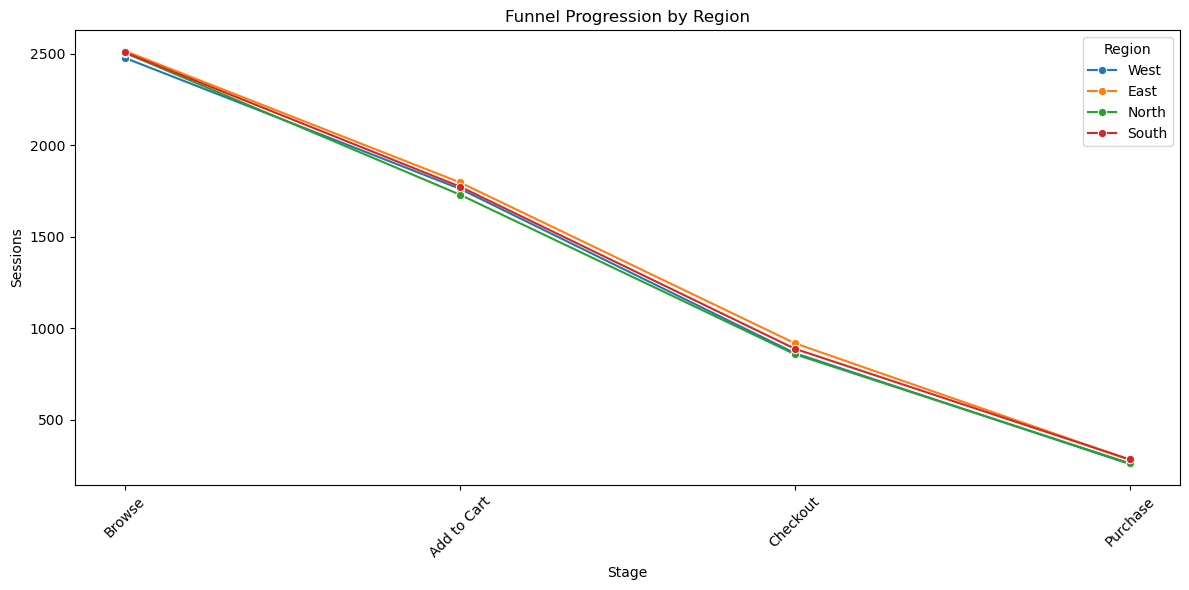

In [27]:
#Regional performance analysis
regional_analysis = session_summary.groupby('Region').agg({
    'Session_ID' : 'count',
    'Revenue': 'sum',
    'Session_Duration_Min': 'mean'
}).rename(columns={'Session_ID': 'Total_Session', 'Revenue': 'Total_Revenue'})

# Add conversion rates by region
regional_conversion = session_summary[session_summary['max_funnel_stage'] == 'Purchase'].groupby('Region').size()
regional_analysis['Converted_Sessions']=regional_conversion
regional_analysis['Conversion_Rate'] = (regional_analysis['Converted_Sessions'] / regional_analysis['Total_Session'] * 100).round(2)
regional_analysis['AOV']=(regional_analysis['Total_Revenue'] / regional_analysis['Converted_Sessions']).round(2)

print('Regional Performance:')
display(regional_analysis)
#Regional funnel visualization
regional_funnel_data = []
for region in df['Region'].unique():
    region_sessions = session_summary[session_summary['Region']==region]
    for stage in funnel_stages:
        if stage =='Browse':
            count = len(region_sessions)
        else:
            count=len(region_sessions[region_sessions['max_funnel_stage'].isin(funnel_stages[funnel_stages.index(stage):])])
        regional_funnel_data.append({'Region':region , 'Stage':stage , 'Sessions': count})
regional_funnel_df = pd.DataFrame(regional_funnel_data)

plt.figure(figsize=(12,6))
sns.lineplot(data=regional_funnel_df , x='Stage' , y='Sessions' , hue='Region' , marker= 'o')
plt.title('Funnel Progression by Region')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()
      
    

Device and Product Category Analysis

Device Performance:


,Total_Sessions,Revenue,Session_Duration_Min,Purchases,Conversion_Rate,AOV
Device,,,,,,
Desktop,3331,399395.43,4.095167,372,11.17,1073.64
Mobile,3345,405451.84,4.061584,363,10.85,1116.95
Tablet,3324,371558.51,4.089350,345,10.38,1076.98


product category performance


,Total_Sessions,Revenue,Purchases,Conversion_Rate,AOV,Revenue_per_session
product_category,,,,,,
Beauty,1978,241834.97,226,11.43,1070.07,122.26
Electronics,2046,226451.63,208,10.17,1088.71,110.68
Fashion,2035,237261.50,220,10.81,1078.46,116.59
Home,1941,232534.83,211,10.87,1102.06,119.80
Sports,2000,238322.85,215,10.75,1108.48,119.16


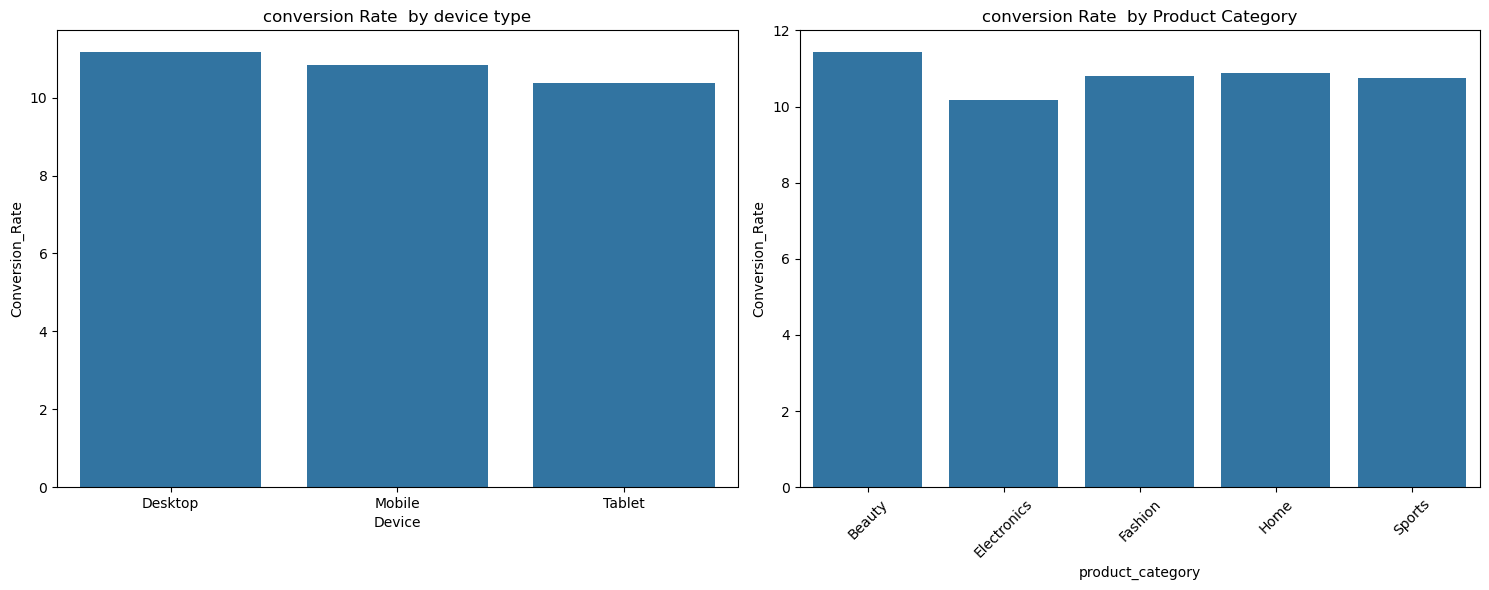

In [28]:
# Device performance 
device_analysis = session_summary.groupby('Device').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Session_Duration_Min' : 'mean',
    'max_funnel_stage': lambda x:(x=='Purchase').sum()
}).rename(columns={'Session_ID': 'Total_Sessions','max_funnel_stage':'Purchases'})
device_analysis['Conversion_Rate']=(device_analysis['Purchases'] / device_analysis['Total_Sessions'] * 100).round(2)
device_analysis['AOV']=(device_analysis['Revenue'] / device_analysis['Purchases']).round(2)

print("Device Performance:")
display(device_analysis)

#product category analysis
product_analysis = session_summary.groupby('product_category').agg({
    'Session_ID' : 'count',
    'Revenue' : 'sum' ,
    'max_funnel_stage' : lambda x: (x == 'Purchase').sum()
}).rename(columns={'Session_ID':'Total_Sessions','max_funnel_stage': 'Purchases'})

product_analysis['Conversion_Rate']=(product_analysis['Purchases']/product_analysis['Total_Sessions']*100).round(2)
product_analysis['AOV'] = (product_analysis['Revenue'] / product_analysis['Purchases']).round(2)
product_analysis['Revenue_per_session']= (product_analysis['Revenue'] / product_analysis['Total_Sessions']).round(2)

print("product category performance")
display(product_analysis)

# combined visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#Device performance
sns.barplot(data=device_analysis.reset_index(),x='Device' , y ='Conversion_Rate' , ax=ax1)
ax1.set_title('conversion Rate  by device type')

# product category performance
sns.barplot(data=product_analysis.reset_index(), x = 'product_category' , y= 'Conversion_Rate' , ax=ax2)
ax2.set_title('conversion Rate  by Product Category')
ax2.tick_params(axis='x' , rotation = 45)

plt.tight_layout()
plt.show()
              
    
      

Time-Based Analysis


Daily performance Trends:


,Daily_Sessions,Daily_Users,Revenue,Daily_Conversions,Daily_Conversion_Rate
Date,,,,,
2025-10-22,300,300,33633.64,31,10.33
2025-10-23,347,347,50983.83,47,13.54
2025-10-24,315,315,39543.10,38,12.06
2025-10-25,364,364,50965.19,42,11.54
2025-10-26,355,355,42548.29,38,10.70
2025-10-27,310,310,41315.66,42,13.55
2025-10-28,347,347,39963.77,31,8.93
2025-10-29,336,336,29960.83,28,8.33
2025-10-30,331,331,35412.95,34,10.27


C:\Users\Ravula preethi\AppData\Local\Temp\ipykernel_2624\1664797211.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



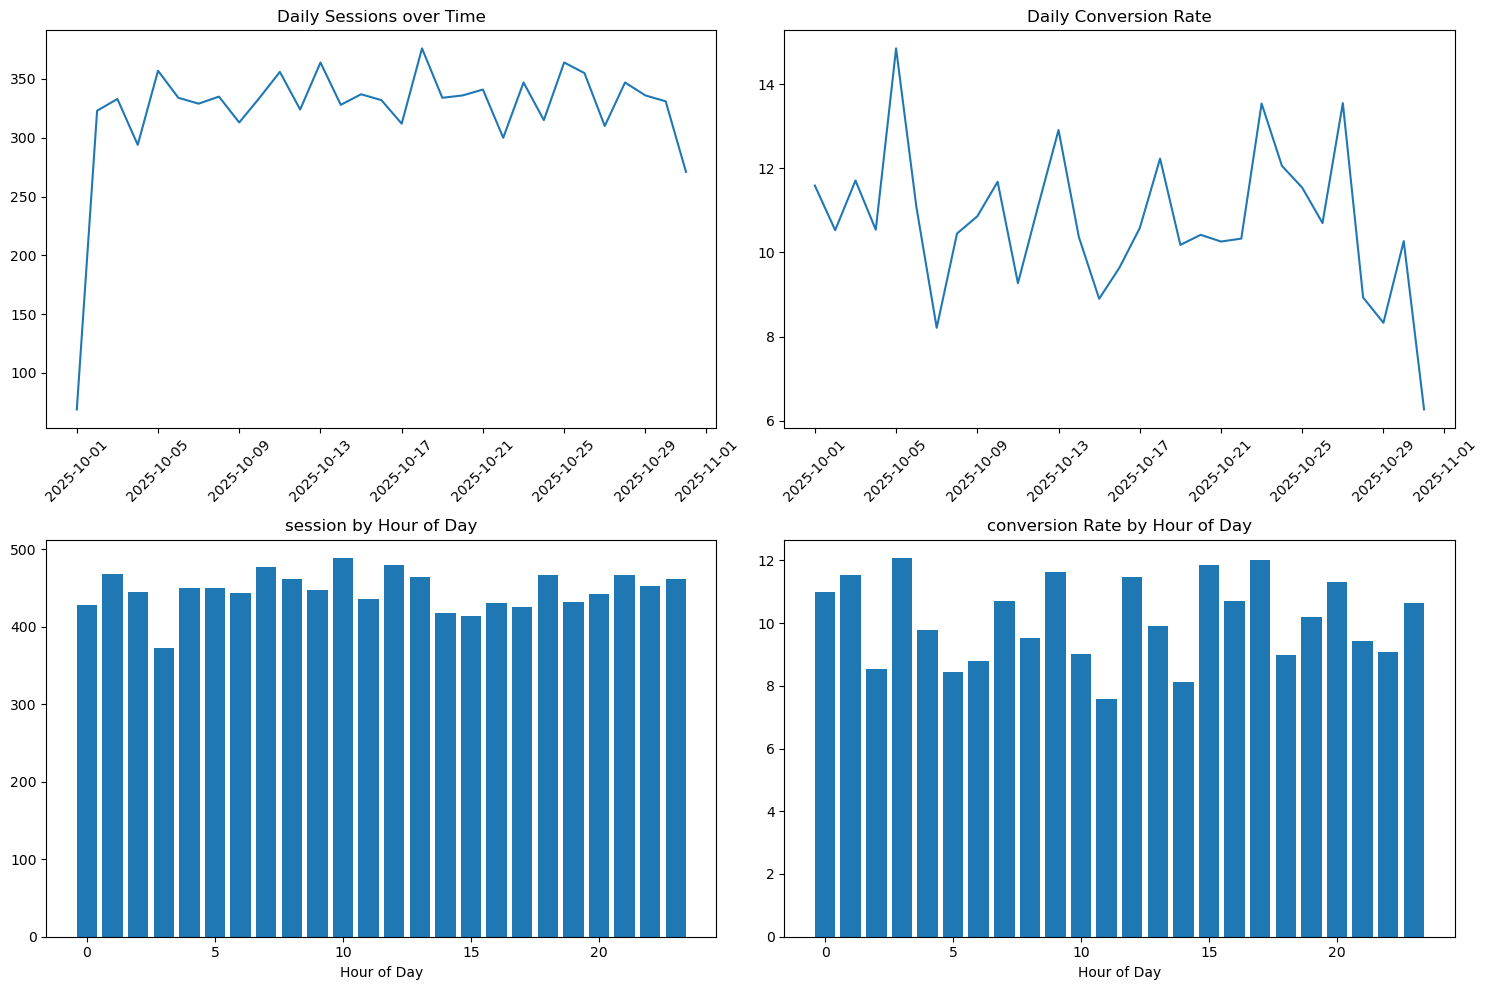

In [29]:
# Daily trends
daily_metrics = df.groupby('Date').agg({
    'Session_ID': 'nunique',
    'User_ID' : 'nunique',
    'Revenue': 'sum'
}).rename(columns={'Session_ID':'Daily_Sessions','User_ID':'Daily_Users'})
#add conversions rates daily
#modify the problematic line to extract date from datetime

daily_conversions = session_summary[session_summary['max_funnel_stage'] =='Purchase'].groupby(
    session_summary['Session_Start'].dt.date
).size()
daily_metrics['Daily_Conversions'] = daily_conversions
daily_metrics['Daily_Conversion_Rate']=(daily_metrics['Daily_Conversions'] / daily_metrics['Daily_Sessions']*100).round(2)

print("Daily performance Trends:")
display(daily_metrics.tail(10))

# hourly patterns
hourly_sessions = df.groupby('hour').agg({
    'Session_ID' : 'nunique',
    'Revenue':'sum'
}).rename(columns={'Session_ID':'Hourly_Sessions'})

hourly_conversions = session_summary[session_summary['max_funnel_stage']=='Purchase']
hourly_conversions['Hour'] = hourly_conversions['Session_Start'].dt.hour
hourly_conversion_counts = hourly_conversions.groupby('Hour').size()
hourly_sessions['Hourly_Conversions'] = hourly_conversion_counts
hourly_sessions['Hourly_Conversion_Rate']= (hourly_sessions['Hourly_Conversions'] / hourly_sessions['Hourly_Sessions']*100).round(2)


#visualization
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2 , figsize=(15,10))

#Daily sessions
ax1.plot(daily_metrics.index, daily_metrics['Daily_Sessions'])
ax1.set_title('Daily Sessions over Time')
ax1.tick_params(axis='x',rotation = 45)


# Daily conversion rate
ax2.plot(daily_metrics.index , daily_metrics['Daily_Conversion_Rate'])
ax2.set_title('Daily Conversion Rate')
ax2.tick_params(axis='x', rotation = 45)

#Hourly session pattern
ax3.bar(hourly_sessions.index, hourly_sessions['Hourly_Sessions'])
ax3.set_title('session by Hour of Day')
ax3.set_xlabel('Hour of Day')

#hourly conversion rate
ax4.bar(hourly_sessions.index, hourly_sessions['Hourly_Conversion_Rate'])
ax4.set_title('conversion Rate by Hour of Day')
ax4.set_xlabel('Hour of Day')
plt.tight_layout()
plt.show()

Advanced Funnel Metrics and KPIs


In [33]:
#calculate adavanced metrics
print("KEY PERFORMANCE INDICATIONS(KPIs)")
print("="*50)
#overall kpis
total_sessions = len(session_summary)
total_revenue = session_summary['Revenue'].sum()
total_orders = len(session_summary[session_summary['max_funnel_stage']=='Purchase'])
overall_conversion_rate = ( total_orders/total_sessions*100)

print(f"overall conversion rate :  {overall_conversion_rate:.2f}%")
print(f"Total Revenue : ${total_revenue:,.2f}")
print(f"Average Order Value:${(total_revenue/total_orders):.2f}")
print(f"Total Sessions: {total_sessions:,}")
print(f"Total Orders:{total_orders:,}")

#funnel efficiency metrics
browse_to_cart = (funnel_df.iloc[1]['Sessions']/funnel_df.iloc[0]['Sessions']*100)
cart_to_checkout = (funnel_df.iloc[2]['Sessions']/funnel_df.iloc[1]['Sessions']*100)
checkout_to_purchase = (funnel_df.iloc[3]['Sessions']/funnel_df.iloc[2]['Sessions']*100)

print(f"\n Stage-to-stage conversion Rates:")
print(f"   Browse → Add to cart : {browse_to_cart:.2f}%")
print(f"   Add to cart → Checkout:{cart_to_checkout:.2f}%")
print(f"   checkout → Purchases: { checkout_to_purchase:.2f}%")


#Revenue per session at each stage
revenue_per_browse = total_revenue /funnel_df.iloc[0]['Sessions']
revenue_per_cart = total_revenue / funnel_df.iloc[1]['Sessions']
revenue_per_checkout = total_revenue/funnel_df.iloc[2]['Sessions']

print(f"\n Revenue per Session by stage:")
print(f" per Browse Session: ${revenue_per_browse:.2f}")
print(f" per cart Session: ${revenue_per_cart:.2f}")
print(f" per checkout Session: ${revenue_per_checkout:.2f}")


#Bounce rate analysis
bounce_sessions = session_summary[session_summary['Bounce_Flag'] =='yes']
bounce_rate = (len(bounce_sessions)/total_sessions *100)
print(f"\n Bounce Rate: {bounce_rate:.2f}%")

# session duration analysis
avg_session_duration = session_summary['Session_Duration_Min'].mean()
print(f" Average Session Duration : {avg_session_duration:2f} minutes")



KEY PERFORMANCE INDICATIONS(KPIs)
overall conversion rate :  10.80%
Total Revenue : $1,176,405.78
Average Order Value:$1089.26
Total Sessions: 10,000
Total Orders:1,080

 Stage-to-stage conversion Rates:
   Browse → Add to cart : 70.59%
   Add to cart → Checkout:49.92%
   checkout → Purchases: 30.65%

 Revenue per Session by stage:
 per Browse Session: $117.64
 per cart Session: $166.65
 per checkout Session: $333.83

 Bounce Rate: 0.00%
 Average Session Duration : 4.082000 minutes


Strategic Recommendations


In [49]:
# generate actionable insights
print("STRATEGIC RECOMMENDATIONS")
print("="*50)

#identify biggest drop-ff points
max_dropoff_stage = funnel_df.loc[funnel_df['Drop_off_Rate'].idxmax()]
print(f" BIGGEST DROP-OFF:{max_dropoff_stage['stage']} stage with {max_dropff_stage['Drop_off_Rate']}%drop-off")

# Best performing channel
best_channel = channel_df.loc[channel_df['Conversion_Rate'].idxmax()]
print(f" BEST PERFORMING CHANNEL : { best_channel['channel']} with {best_channel['Conversion_Rate']}%conversion")

#Best performing regoin
best_region = regional_analysis.loc[regional_analysis['Conversion_Rate'].idxmax()]
print(f" BEST PERFORMING REGION : {best_region.name} with {best_region['Conversion_Rate']}% conversion")

#Best performing product category 
best_category = product_analysis.loc[product_analysis['Conversion_Rate'].idxmax()]
print(f" BEST PERFORMING CATEGORY : {best_category.name} with {best_category['Conversion_Rate']}% conversion")

print(f"\n RECOMMENDED ACTIONS:")
print(f"1 Address{max_dropoff_stage['stage']} stage drop-off through Ux improvements")
print(f"2 Allocate more budget to {best_channel['channel']}channel")
print(f"3 Replicate{best_region.name} region strategies in underperforming regions")
print(f"4 promote{best_category.name} category to improve overall conversion")
print(f"5 focus on cart abandonment recovery for {funnel_df.iloc[2]['Drop_off_Rate']}% of users")

# calculate potential revenue opportunities
cart_abandoment_opportunity = funnel_df.iloc[2]['Sessions']* product_analysis['AOV'].mean()
print(f"\n REVENUE OPPORTUNITY")
print(f" Cart abandoment recovery : ${cart_abandoment_opportunity:,.2f} potential revenue")




STRATEGIC RECOMMENDATIONS
 BIGGEST DROP-OFF:Purchase stage with 69.35%drop-off
 BEST PERFORMING CHANNEL : Organic with 11.190760653126244%conversion
 BEST PERFORMING REGION : South with 11.25% conversion
 BEST PERFORMING CATEGORY : Beauty with 11.43% conversion

 RECOMMENDED ACTIONS:
1 AddressPurchase stage drop-off through Ux improvements
2 Allocate more budget to Organicchannel
3 ReplicateSouth region strategies in underperforming regions
4 promoteBeauty category to improve overall conversion
5 focus on cart abandonment recovery for 50.08% of users

 REVENUE OPPORTUNITY
 Cart abandoment recovery : $3,839,595.34 potential revenue


Analysis complete! Report exported to 'funnel_analysis_report.xlsx'
Key visualizations saved!


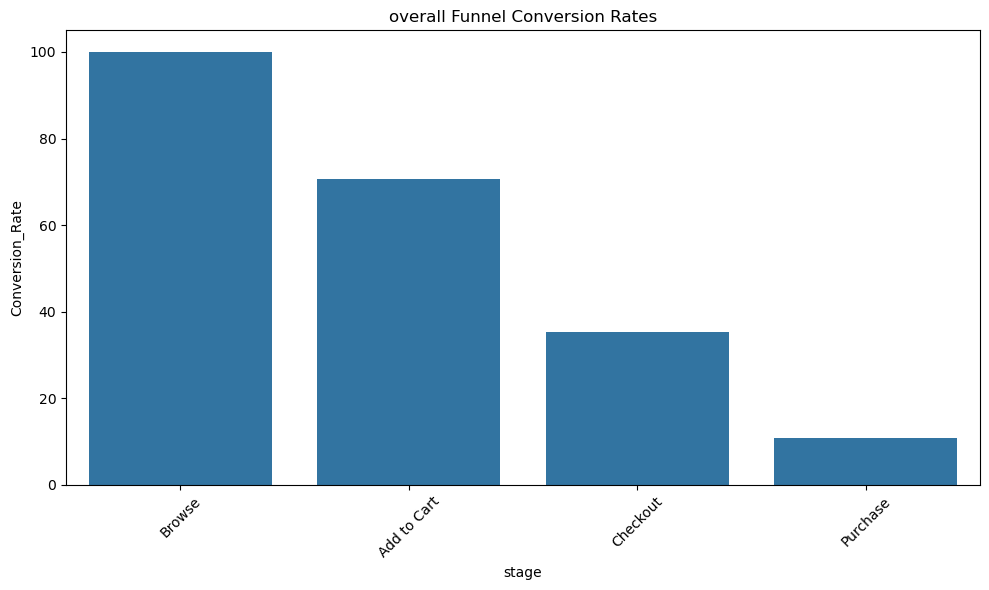

In [51]:
#Create comprehensive report
report_data = {
    'Overall_Funnel': funnel_df,
    'Channel_Performance' : channel_df,
    'Regional_Analysis':regional_analysis,
    'Device_Performance': device_analysis,
    'Product_Performance': product_analysis,
    'Daily_Trends': daily_metrics,
    'Hourly_Patterns': hourly_sessions
}

#Export to excel 
with pd.ExcelWriter('funnel_analysis_report.xlsx') as writer:
    for sheet_name, data in report_data.items():
        data.to_excel(writer,sheet_name = sheet_name , index = False)

print("Analysis complete! Report exported to 'funnel_analysis_report.xlsx'")

#save key visualizations
plt.figure(figsize=(10,6))
sns.barplot(data = funnel_df, x = 'stage' , y= 'Conversion_Rate')
plt.title('overall Funnel Conversion Rates')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('funnel_conversion_rates.png' , dpi=300,bbox_inches = 'tight')

print("Key visualizations saved!")

            
